In [4]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd

In [5]:
QKE = pd.make_data_dictionary("../results/anvil/51-full_QKE.csv", "../results/anvil/51-full_QKE-eps.csv")
coherent = pd.make_data_dictionary("../results/coherent_only_run.csv", "../results/coherent_only_eps.csv")
thermal = pd.make_data_dictionary("../results/anvil/07-nu_nu_coll.csv", "../results/anvil/06-nu_e_coll-eps.csv")

In [6]:
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [7]:
e_color = '#008185'
m_color = '#5CBE00'
index_plots = [15, 45]

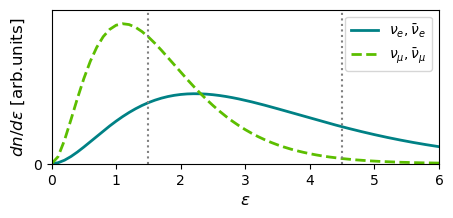

In [8]:
eps_max = 6

eps = QKE['eps']
fe = QKE['dnde'][pd.NU_E]
fm = QKE['dnde'][pd.NU_MU]
plt.figure(figsize=(5,2))
plt.plot(eps, fe[0,:], c=e_color, lw=2, label=r"$\nu_e, \bar\nu_e$")
plt.plot(eps, fm[0,:], c=m_color, lw=2, ls="--", label=r"$\nu_\mu, \bar\nu_\mu$")
plt.xlim(0, eps_max)
plt.ylim(0, max(np.max(fe[0,:]), np.max(fm[0,:]))*1.1)
plt.legend()

plt.xlabel(r"$\epsilon$", fontsize=12)
plt.ylabel(r"$dn/d\epsilon$ [arb.units]", fontsize=12)

plt.axvline(eps[index_plots[0]], c='0.50', ls=":")
plt.axvline(eps[index_plots[1]], c='0.50', ls=":")

plt.yticks([0])
plt.show()

[Text(0, 0, '0'), Text(4, 0, '4'), Text(8, 0, '8'), Text(12, 0, '12')]

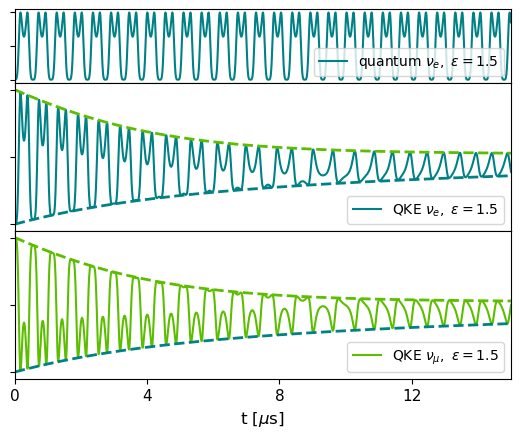

In [9]:
eps = QKE['eps']

fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, sharey=True, height_ratios=[0.2,0.4,0.4])
plt.subplots_adjust(hspace=0)

ax[0].plot(coherent['time'], coherent['f'][pd.NU_E][:, index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

ax[1].plot(QKE['time'], QKE['f'][pd.NU_E][:, index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))
ax[1].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=e_color, ls="--", lw=2)
ax[1].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=m_color, ls="--", lw=2)

ax[2].plot(QKE['time'], QKE['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=m_color, label=r"QKE $\nu_\mu,~\epsilon={:.2}$".format(eps[index_plots[0]]))
ax[2].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=e_color, ls="--", lw=2)
ax[2].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[0]] * eps[index_plots[0]]**2/(2*np.pi**2), c=m_color, ls="--", lw=2)

#ax[2].set_xlim(0,min(np.max(coherent['time']), np.max(QKE['time'])))
ax[2].set_xlim(0, 15)
ax[2].set_xlabel(r"t [$\mu$s]", fontsize=12)

#ax[0].set_yticks([np.min(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2), np.max(coherent[1][:,index_plots[0]]*eps[index_plots[0]]**2)])
#ax[0].set_yticks([])

ytickmin = np.min(coherent['f'][pd.NU_E][:,index_plots[0]]) * eps[index_plots[0]]**2/(2*np.pi**2)
ytickmax = np.max(coherent['f'][pd.NU_E][:,index_plots[0]]) * eps[index_plots[0]]**2/(2*np.pi**2)

ax[0].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
ax[0].set_yticklabels(["","",""])
#fig.supylabel(r"$dn/d\epsilon$ for $\epsilon = 1.5$", fontsize=12)

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')
ax[2].legend(loc='lower right')

ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

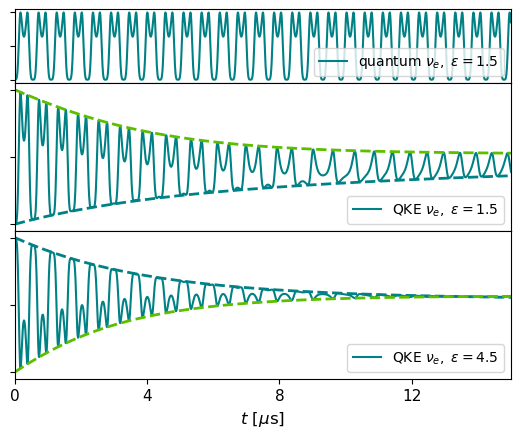

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True, height_ratios=[0.2,0.4,0.4])
plt.subplots_adjust(hspace=0)

eps = QKE['eps']

ax[0].plot(coherent['time'], coherent['f'][pd.NU_E][:,index_plots[0]]*eps[index_plots[0]]**2/(2*np.pi**2), c=e_color, label=r"quantum $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[0]]))

for i in range(2):
    ax[i+1].plot(QKE['time'], QKE['f'][pd.NU_E][:,index_plots[i]]*eps[index_plots[i]]**2/(2*np.pi**2), c=e_color, label=r"QKE $\nu_e,~\epsilon={:.2}$".format(eps[index_plots[i]]))
    ax[i+1].plot(thermal['time'], thermal['f'][pd.NU_E][:,index_plots[i]]*eps[index_plots[i]]**2/(2*np.pi**2), ls="--", lw=2, c=e_color)
    ax[i+1].plot(thermal['time'], thermal['f'][pd.NU_MU][:,index_plots[i]]*eps[index_plots[i]]**2/(2*np.pi**2), ls="--", lw=2, c=m_color)

ax[0].set_xlim(0,15)
ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

for i in range(3):
    ytickmin = np.min(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2/(2*np.pi**2)
    ytickmax = np.max(coherent['f'][pd.NU_E][:,index_plots[i//2]]) * eps[index_plots[i//2]]**2/(2*np.pi**2)

    ax[i].set_yticks([ytickmin, 0.5*(ytickmin+ytickmax), ytickmax])
    ax[i].set_yticklabels(["","",""])
    ax[i].legend(loc='lower right')


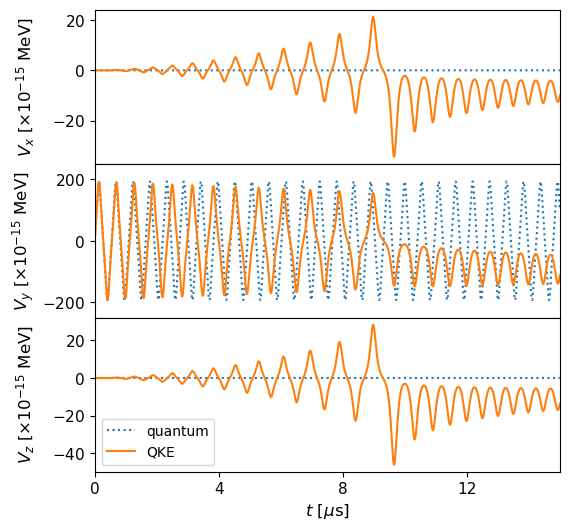

In [11]:
fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=1, sharex=True)
plt.subplots_adjust(hspace=0)

V_coherent = pd.V_mat(coherent)
V_QKE = pd.V_mat(QKE)

for i in range(3):
    ax[i].plot(coherent['time'], V_coherent[i,:]*1e15, ls=":", label="quantum")
    ax[i].plot(QKE['time'], V_QKE[i,:]*1e15, label="QKE")
ax[0].set_xlim([0,15])

ax[0].set_ylabel(r"$V_x~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[2].set_ylabel(r"$V_z~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
ax[2].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
ax[2].legend(loc='lower left')

fig.align_ylabels()
ax[2].set_xticks([0, 4, 8, 12])
ax[2].set_xticklabels([0,4,8,12],fontsize=11)

ax[0].set_yticks([-20,0,20], [r"$-20$",r"$0$",r"$20$"], fontsize=11)
ax[1].set_yticks([-200,0,200], [r"$-200$",r"$0$",r"$200$"], fontsize=11)
ax[1].set_ylim([-250,250])
ax[2].set_yticks([-40, -20,0,20], [r"$-40$",r"$-20$",r"$0$",r"$20$"], fontsize=11)

fig.align_ylabels()


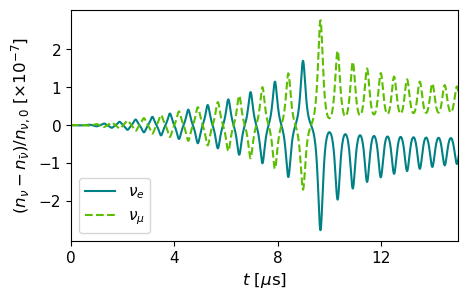

In [71]:
nQKE = pd.num_density(QKE)

plt.figure(figsize=(5,3))
plt.plot(QKE['time'], (nQKE[pd.NU_E,:]-nQKE[pd.ANTI_NU_E,:])/nQKE[pd.NU_E,0]*1e7, c=e_color, label=r"$\nu_e$")
plt.plot(QKE['time'], (nQKE[pd.NU_MU,:]-nQKE[pd.ANTI_NU_MU,:])/nQKE[pd.NU_MU,0]*1e7, c=m_color, ls='--', label=r"$\nu_\mu$")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$(n_\nu - n_{\bar\nu})/n_{\nu,0}~[\times 10^{-7}]$", fontsize=12)

plt.legend(loc='lower left', fontsize=11)

plt.xticks([0, 4, 8, 12], fontsize=11)
plt.yticks([-2,-1, 0,1,2], fontsize=11)
plt.xlim(0, 15)
plt.show()

In [13]:
pd.run_coherentsolve("asym")

In [14]:
asym = pd.make_data_dictionary("asym_run.csv", "asym_eps.csv")

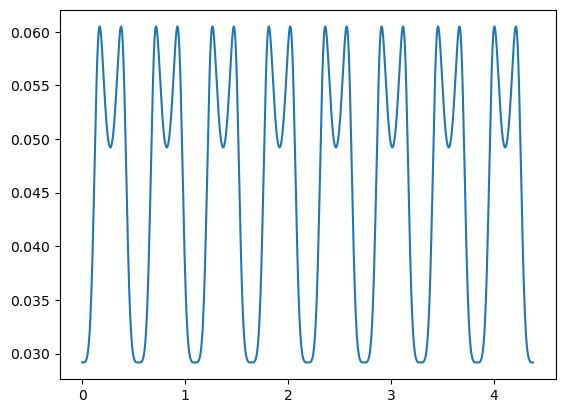

In [15]:
plt.plot(asym['time'], asym['f'][pd.NU_E][:,15])

In [40]:
MHz1 = [[1, 100], [3.07e-16, 3.07e-20]]
pd.find_coherent_frequency_MHz(Tcm=1, dm2=3.07e-16), pd.find_coherent_frequency_MHz(Tcm=100, dm2=3.07e-20)

(0.9993827121956699, 0.9993278499842436)

In [42]:
MHz10 = [[2.5, 100], [49.12e-16, 3.07e-18]]
pd.find_coherent_frequency_MHz(Tcm=2.5, dm2=49.12e-16), pd.find_coherent_frequency_MHz(Tcm=100, dm2=3.07e-18)

(9.99372115748513, 9.993272770600255)

In [44]:
MHz01 = [[1, 100], [3.07e-18, 3.07e-22]]
pd.find_coherent_frequency_MHz(Tcm=1, dm2=3.07e-18), pd.find_coherent_frequency_MHz(Tcm=100, dm2=3.07e-22)

(0.09993313293636863, 0.09993246143182495)

In [51]:
eq_osc = [[10, 100], [1e-18*(10/32)**8, 1e-18*(100/32)**8]]

Text(0, 0.5, '$\\Delta m^2~~[{\\rm MeV}^2]$')

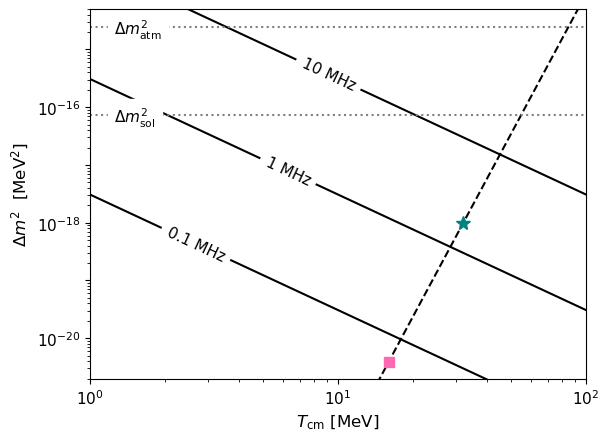

In [53]:
plt.loglog(MHz1[0], MHz1[1], c='k')
plt.text(5, 4.5e-18, "1 MHz", backgroundcolor='white', rotation=-25, fontsize=11)
plt.loglog(MHz01[0], MHz01[1], c='k')
plt.text(2, 2.2e-19, "0.1 MHz", backgroundcolor='white', rotation=-25, fontsize=11)
plt.loglog(MHz10[0], MHz10[1], c='k')
plt.text(7, 2.e-16, "10 MHz", backgroundcolor='white', rotation=-25, fontsize=11)
plt.loglog(eq_osc[0], eq_osc[1], ls='--', c='k')
plt.loglog(32, 1.e-18, '*', ms=10, c=e_color)
plt.loglog(16, 3.90625e-21, 's', ms=7, c='hotpink')

plt.axhline(7.41e-17, c='0.50', ls=':')
plt.text(1.25, 5.5e-17, r"$\Delta m^2_{\rm sol}$", backgroundcolor='white', fontsize=11)
plt.axhline(2.44e-15, c='0.50', ls=':')
plt.text(1.25, 1.8e-15, r"$\Delta m^2_{\rm atm}$", backgroundcolor='white', fontsize=11)


plt.ylim(2e-21, 5e-15)
plt.xlim(1, 100)
plt.yticks([1e-20, 1e-19, 1e-18, 1e-17, 1e-16, 1e-15], [r"$10^{-20}$", "", r"$10^{-18}$", "", r"$10^{-16}$", ""], fontsize=11)
plt.xticks(fontsize=11)

plt.xlabel(r"$T_{\rm cm}$ [MeV]", fontsize=12)
plt.ylabel(r"$\Delta m^2~~[{\rm MeV}^2]$", fontsize=12)

In [56]:
match = pd.make_data_dictionary("../results/anvil/52-full_QKE_matchT16.csv", "../results/anvil/51-full_QKE-eps.csv")
dm4 = pd.make_data_dictionary("../results/anvil/53-full_QKE_dmx4.csv", "../results/anvil/51-full_QKE-eps.csv")

In [62]:
nmatch = pd.num_density(match)
n4 = pd.num_density(dm4)

Text(0.5, 0, '$t_{16}~~[\\mu$s]')

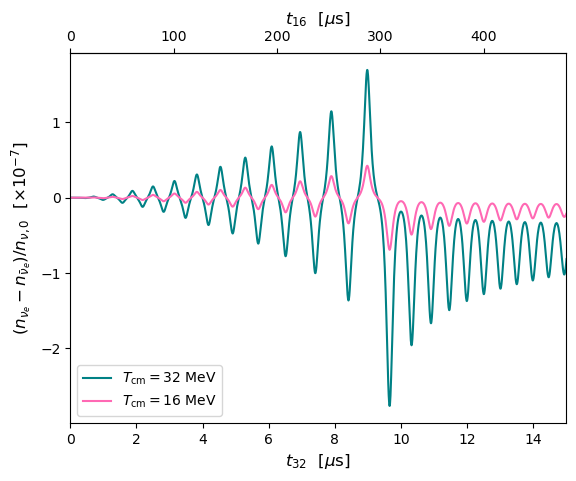

In [73]:
fig, ax = plt.subplots()
ax.plot(QKE['time'], (nQKE[0]-nQKE[2])/nQKE[0][0] * 1e7, c=e_color, label=r"$T_{\rm cm} = 32~{\rm MeV}$")
ax.plot(match['time']/2**5, (nmatch[0]-nmatch[2])/nmatch[0][0] * 1e7, c='hotpink', label=r"$T_{\rm cm} = 16~{\rm MeV}$")

ax.set_xlabel(r"$t_{32}~~[\mu$s]", fontsize=12)
ax.set_ylabel(r"$(n_{\nu_e} - n_{\bar\nu_e})/n_{\nu,0}~~[\times 10^{-7}]$", fontsize=12)
ax.set_xlim(0,15)

ax.legend(loc='lower left')

match_ax = ax.secondary_xaxis('top', functions=(lambda x: x*2**5, lambda x: x/2**5))
match_ax.set_xlabel(r"$t_{16}~~[\mu$s]", fontsize=12)

(0.0, 15.0)

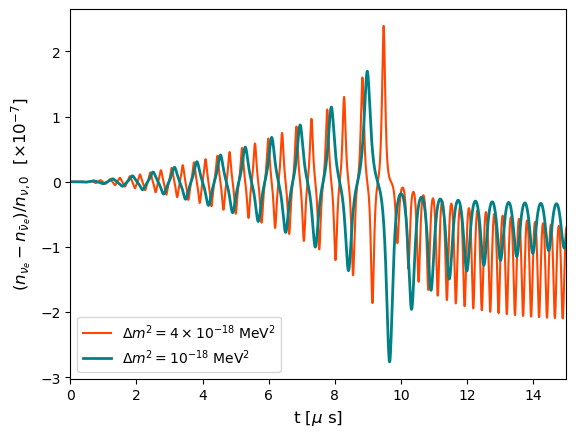

In [86]:
plt.plot(dm4['time'], (n4[0]-n4[2])/n4[0][0]* 1e7/2, c='orangered', label=r"$\Delta m^2 = 4 \times 10^{-18}~{\rm MeV}^2$")
plt.plot(QKE['time'], (nQKE[0]-nQKE[2])/nQKE[0][0] * 1e7, c=e_color, label=r"$\Delta m^2 = 10^{-18}~{\rm MeV}^2$", lw=2)
plt.legend(loc='lower left')
plt.xlabel(r"t [$\mu$ s]", fontsize=12)
plt.ylabel(r"$(n_{\nu_e} - n_{\bar\nu_e})/n_{\nu,0}~~[\times 10^{-7}]$", fontsize=12)
plt.xlim(0,15)